# Mixture Density Networks on a 2D Synthetic Regression Problem

This notebook is a starting point for the MDN assignment. We study a one-dimensional input $x$ and a one-dimensional output $y$, so every observation is a point in the 2D plane. The conditional distribution $p(y\mid x)$ is deliberately multimodal: for the same input, the response may come from either of two smooth branches.

The experiment compares three probabilistic assumptions:
1. A deterministic neural network that predicts only a conditional mean.
2. A single-Gaussian regression network that predicts a mean and standard deviation.
3. A mixture density network (MDN) that predicts mixture weights, means, and scales.

We use a fixed train/test split, evaluate negative log likelihood (NLL) on both sets, and visualize predictive samples and density contours. The results here are intended to be extended into the report with additional mixture counts, uncertainty analysis, and a higher-dimensional real dataset.

In [10]:
import math
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.distributions import Categorical, Normal, MixtureSameFamily

# Fix random seeds so the experiment is reproducible.
SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_default_dtype(torch.float32)
# Use a GPU when available; otherwise run on the CPU.
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using {DEVICE}')

Using cuda


## 1. Generate a multimodal conditional distribution

The latent branch is sampled uniformly. Both branches are nonlinear and have different slopes, which makes a mean-only model average across modes. Small Gaussian observation noise keeps the likelihood well behaved while preserving the two modes.

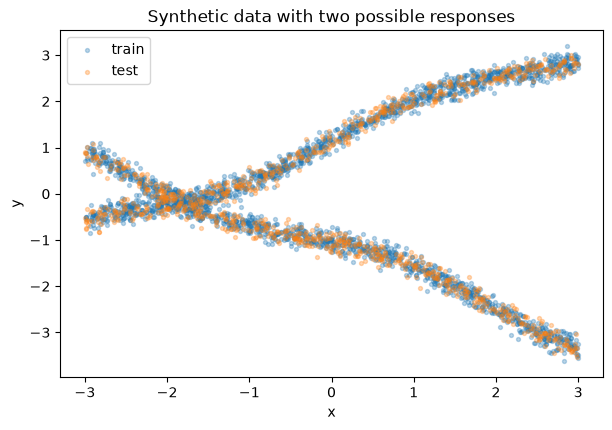

In [11]:
def make_data(n: int, seed: int):
    # Sample inputs and randomly choose one of two response branches.
    generator = torch.Generator().manual_seed(seed)
    x = 6.0 * torch.rand(n, 1, generator=generator) - 3.0
    branch = torch.randint(0, 2, (n, 1), generator=generator)
    upper = 0.65 * x + 1.15 + 0.25 * torch.sin(1.4 * x)
    lower = -0.65 * x - 1.15 + 0.25 * torch.sin(1.4 * x + 0.5)
    clean_y = torch.where(branch == 1, upper, lower)
    # Add observation noise so each branch has a small amount of spread.
    y = clean_y + 0.13 * torch.randn(n, 1, generator=generator)
    return x, y

x_train, y_train = make_data(2400, SEED)
x_test, y_test = make_data(1000, SEED + 1)

plt.figure(figsize=(7, 4.5))
plt.scatter(x_train[:, 0], y_train[:, 0], s=8, alpha=0.3, label='train')
plt.scatter(x_test[:, 0], y_test[:, 0], s=8, alpha=0.3, label='test')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Synthetic data with two possible responses')
plt.legend()
plt.show()

## 2. Models and stable likelihoods

All models share a small multilayer perceptron. The deterministic baseline is trained with mean squared error. The Gaussian models use `softplus` for positive scales and compute the log likelihood with PyTorch distributions. Computing the MDN likelihood in log space avoids underflow when several component densities are combined.

In [21]:
class Trunk(nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        # Shared nonlinear feature extractor used by every regressor.
        self.net = nn.Sequential(
            nn.Linear(1, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
        )

    def forward(self, x):
        return self.net(x)


class DeterministicRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.trunk = Trunk()
        # One output gives a point prediction for y.
        self.output = nn.Linear(64, 1)

    def forward(self, x):
        return self.output(self.trunk(x))


class GaussianRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.trunk = Trunk()
        # Two outputs represent the mean and an unconstrained scale value.
        self.output = nn.Linear(64, 2)

    def forward(self, x):
        mean, raw_scale = self.output(self.trunk(x)).chunk(2, dim=-1)
        # Convert the raw value into a positive standard deviation.
        scale = torch.nn.functional.softplus(raw_scale) + 1e-3
        return mean, scale


class MDN(nn.Module):
    def __init__(self, components=2):
        super().__init__()
        self.components = components
        self.trunk = Trunk()
        # Each component needs one logit, mean, and scale parameter.
        self.output = nn.Linear(64, 3 * components)

    def forward(self, x):
        # Split the head output into one group for each Gaussian parameter.
        logits, means, raw_scales = self.output(self.trunk(x)).chunk(3, dim=-1)
        # Convert raw scales into positive standard deviations.
        scales = torch.nn.functional.softplus(raw_scales) + 1e-3
        return logits, means, scales


def gaussian_log_prob(mean, scale, y):
    # Compute the log probability of observed target values under one Gaussian.
    return Normal(mean, scale).log_prob(y).sum(dim=-1)


def mdn_log_prob(logits, means, scales, y):
    # Compute each component's log probability for the observed target values.
    component_log_probs = Normal(means, scales).log_prob(y)
    # Combine weighted component probabilities stably in log space.
    return torch.logsumexp(
        torch.log_softmax(logits, dim=-1) + component_log_probs, dim=-1
    )


def mdn_distribution(model, x):
    # Build a reusable PyTorch distribution for sampling or scoring predictions.
    logits, means, scales = model(x)
    mixture = Categorical(logits=logits)
    components = Normal(means, scales)
    return MixtureSameFamily(mixture, components)

## 3. Training utilities

The same optimizer and minibatch schedule are used for each model. The returned history lets us compare optimization behavior rather than only final test metrics.

In [22]:
def loss_for(model, x, y, kind):
    # Select the objective that matches the model's output type.
    if kind == 'deterministic':
        return ((model(x) - y) ** 2).mean()
    if kind == 'gaussian':
        mean, scale = model(x)
        return -gaussian_log_prob(mean, scale, y).mean()
    logits, means, scales = model(x)
    return -mdn_log_prob(logits, means, scales, y).mean()


def train_model(model, kind, epochs=500, batch_size=128, learning_rate=2e-3):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    history = {'train': [], 'test': []}
    xtr, ytr = x_train.to(DEVICE), y_train.to(DEVICE)
    xte, yte = x_test.to(DEVICE), y_test.to(DEVICE)
    for epoch in range(epochs):
        # Shuffle the training examples before creating minibatches.
        permutation = torch.randperm(len(xtr), device=DEVICE)
        model.train()
        for indices in permutation.split(batch_size):
            optimizer.zero_grad()
            loss = loss_for(model, xtr[indices], ytr[indices], kind)
            loss.backward()
            optimizer.step()
        if epoch == 0 or (epoch + 1) % 10 == 0:
            # Record full-dataset metrics periodically for the learning curves.
            model.eval()
            with torch.no_grad():
                history['train'].append(loss_for(model, xtr, ytr, kind).item())
                history['test'].append(loss_for(model, xte, yte, kind).item())
    return model, history


def evaluate(model, kind, x, y):
    model.eval()
    with torch.no_grad():
        # Report metrics without building a gradient graph.
        if kind == 'deterministic':
            prediction = model(x.to(DEVICE)).cpu()
            return {'mse': ((prediction - y) ** 2).mean().item()}
        if kind == 'gaussian':
            mean, scale = model(x.to(DEVICE))
            nll = -gaussian_log_prob(mean, scale, y.to(DEVICE)).mean().item()
            return {'nll': nll, 'mse_mean': ((mean.cpu() - y) ** 2).mean().item()}
        logits, means, scales = model(x.to(DEVICE))
        nll = -mdn_log_prob(logits, means, scales, y.to(DEVICE)).mean().item()
        mean_prediction = (torch.softmax(logits, -1) * means).sum(-1, keepdim=True).cpu()
        return {'nll': nll, 'mse_mean': ((mean_prediction - y) ** 2).mean().item()}

## 4. Fit the baselines and a two-component MDN

The deterministic loss is MSE, while the reported Gaussian and MDN losses are NLL. Their numerical values should therefore be compared within the probabilistic models, while the mean-prediction MSE provides a common point estimate comparison.

In [23]:
# Fit each model using the same data split and training procedure.
deterministic, deterministic_history = train_model(DeterministicRegressor(), 'deterministic')
gaussian, gaussian_history = train_model(GaussianRegressor(), 'gaussian')
mdn2, mdn2_history = train_model(MDN(components=2), 'mdn')

# Compare likelihood metrics and point-prediction errors on train and test data.
print('Deterministic train/test:', evaluate(deterministic, 'deterministic', x_train, y_train), evaluate(deterministic, 'deterministic', x_test, y_test))
print('Gaussian train/test:', evaluate(gaussian, 'gaussian', x_train, y_train), evaluate(gaussian, 'gaussian', x_test, y_test))
print('MDN-2 train/test:', evaluate(mdn2, 'mdn', x_train, y_train), evaluate(mdn2, 'mdn', x_test, y_test))

Deterministic train/test: {'mse': 2.702784776687622} {'mse': 2.6951282024383545}
Gaussian train/test: {'nll': 1.3459173440933228, 'mse_mean': 2.7040441036224365} {'nll': 1.3780808448791504, 'mse_mean': 2.6912221908569336}
MDN-2 train/test: {'nll': -0.015330473892390728, 'mse_mean': 2.704662322998047} {'nll': 0.02020992338657379, 'mse_mean': 2.6917307376861572}


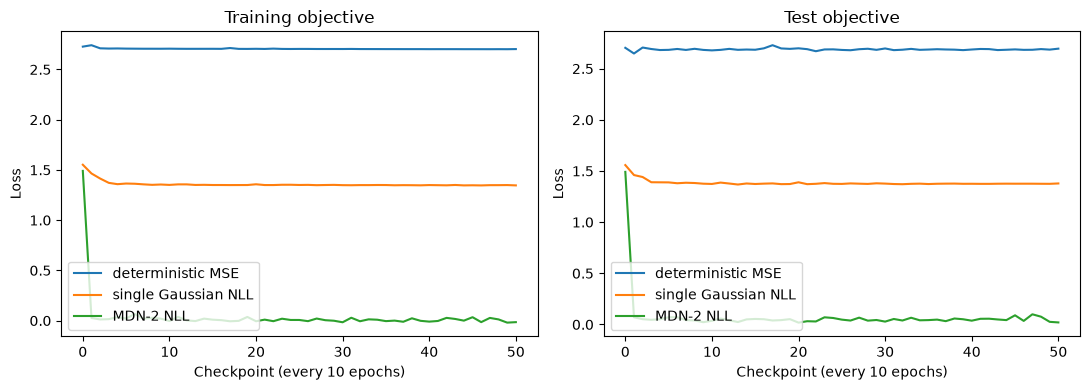

In [24]:
def plot_training_histories(histories):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    # Plot the objective on both the training and held-out test sets.
    for name, history in histories.items():
        axes[0].plot(history['train'], label=name)
        axes[1].plot(history['test'], label=name)
    axes[0].set_title('Training objective')
    axes[1].set_title('Test objective')
    for axis in axes:
        axis.set_xlabel('Checkpoint (every 10 epochs)')
        axis.set_ylabel('Loss')
        axis.legend()
    plt.tight_layout()
    plt.show()

plot_training_histories({
    'deterministic MSE': deterministic_history,
    'single Gaussian NLL': gaussian_history,
    'MDN-2 NLL': mdn2_history,
})

## 5. Visualize predictive behavior

A useful qualitative test is whether samples from the MDN follow both branches. The deterministic prediction should pass between the branches, and the single Gaussian should represent the two modes with one broad distribution.

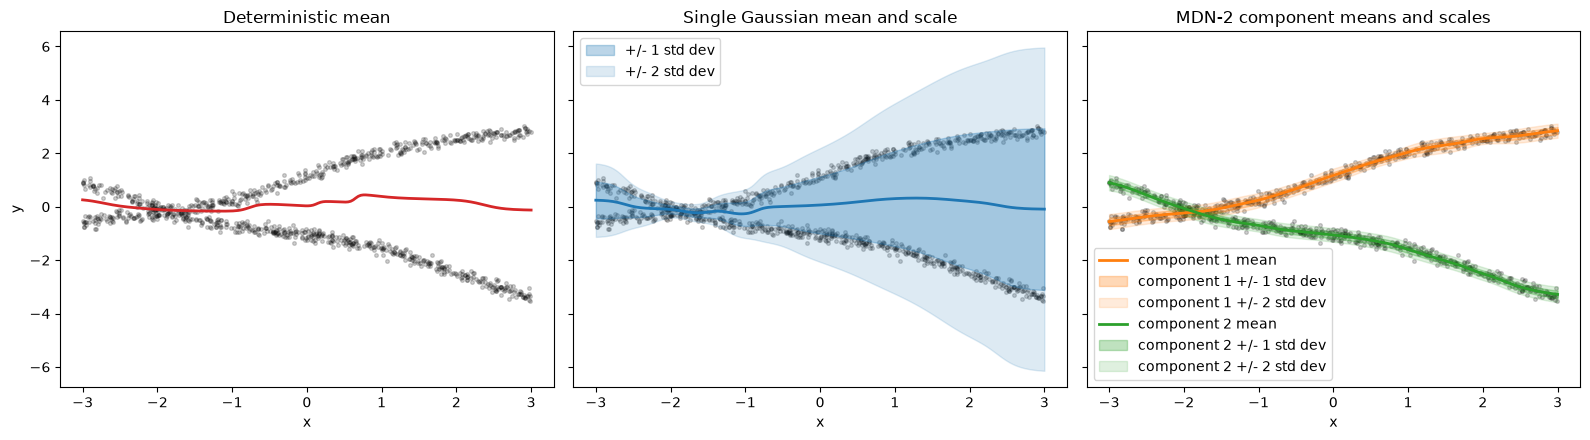

In [ ]:
x_grid = torch.linspace(-3, 3, 180).reshape(-1, 1).to(DEVICE)
with torch.no_grad():
    deterministic_mean = deterministic(x_grid).cpu()
    gaussian_mean, gaussian_scale = gaussian(x_grid)
    gaussian_mean, gaussian_scale = gaussian_mean.cpu(), gaussian_scale.cpu()
    mdn_logits, mdn_means, mdn_scales = mdn2(x_grid)
    mdn_weights = torch.softmax(mdn_logits, -1).cpu()
    mdn_means, mdn_scales = mdn_means.cpu(), mdn_scales.cpu()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharex=True, sharey=True)
for axis in axes:
    axis.scatter(x_test[:, 0], y_test[:, 0], s=7, alpha=0.18, color='black')
axes[0].plot(x_grid.cpu(), deterministic_mean, color='tab:red', linewidth=2)
axes[0].set_title('Deterministic mean')
axes[1].plot(x_grid.cpu(), gaussian_mean, color='tab:blue', linewidth=2)
axes[1].fill_between(
    x_grid[:, 0].cpu(),
    (gaussian_mean - gaussian_scale)[:, 0], # 1 standard deviation below the mean
    (gaussian_mean + gaussian_scale)[:, 0], # 1 standard deviation above the mean
    color='tab:blue',
    alpha=0.30,
    label='mean +/- 1 std dev'
)
axes[1].fill_between(
    x_grid[:, 0].cpu(),
    (gaussian_mean - 2 * gaussian_scale)[:, 0], # 2 standard deviations below the mean
    (gaussian_mean + 2 * gaussian_scale)[:, 0], # 2 standard deviations above the mean
    color='tab:blue',
    alpha=0.15,
    label='mean +/- 2 std dev'
)
axes[1].set_title('Single Gaussian mean and scale')
axes[1].legend()

# Show each MDN component like the single-Gaussian panel: mean plus approximately 95% spread.
component_colors = ['tab:orange', 'tab:green']
for component, color in enumerate(component_colors):
    axes[2].plot(
        x_grid[:, 0].cpu(),
        mdn_means[:, component],
        color=color,
        linewidth=2,
        label=f'component {component + 1} mean'
    )
    axes[2].fill_between(
        x_grid[:, 0].cpu(),
        (mdn_means[:, component] - 1 * mdn_scales[:, component]).cpu(),
        (mdn_means[:, component] + 1 * mdn_scales[:, component]).cpu(),
        color=color,
        alpha=0.30,
        label=f'component {component + 1} +/- 1 std dev'
    )
    axes[2].fill_between(
        x_grid[:, 0].cpu(),
        (mdn_means[:, component] - 2 * mdn_scales[:, component]).cpu(),
        (mdn_means[:, component] + 2 * mdn_scales[:, component]).cpu(),
        color=color,
        alpha=0.15,
        label=f'component {component + 1} +/- 2 std dev'
    )

axes[2].set_title('MDN-2 component means and scales')
axes[2].legend()
for axis in axes:
    axis.set_xlabel('x')
axes[0].set_ylabel('y')
plt.tight_layout()
plt.show()

TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

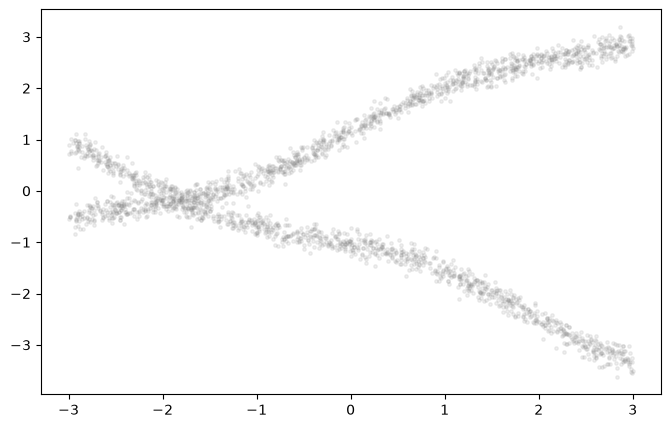

In [28]:
sample_count = 1600
x_sample = torch.linspace(-3, 3, 80).reshape(-1, 1).to(DEVICE)
with torch.no_grad():
    # Draw many samples to reveal the two learned conditional branches.
    samples = mdn_distribution(mdn2, x_sample).sample((sample_count,)).cpu()

plt.figure(figsize=(8, 5))
plt.scatter(x_train[:, 0], y_train[:, 0], s=6, alpha=0.12, color='gray', label='training data')
plt.scatter(x_sample.repeat(sample_count, 1).reshape(-1), samples.reshape(-1), s=1, alpha=0.04, color='tab:orange', label='MDN samples')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Samples from the learned MDN distribution')
plt.legend(markerscale=5)
plt.show()

## 6. Compare mixture counts

The assignment asks for a comparison across numbers of mixture components. This compact sweep is a first experiment; repeat it with several random seeds and report mean and standard deviation in the final write-up. A component count larger than the true number of modes can still improve likelihood by modeling tails, but it may also create redundant components or overfit.

In [ ]:
mixture_results = []
for components in [1, 2, 3, 5]:
    # Compare models with different numbers of Gaussian components.
    model, history = train_model(MDN(components=components), 'mdn', epochs=400)
    train_metrics = evaluate(model, 'mdn', x_train, y_train)
    test_metrics = evaluate(model, 'mdn', x_test, y_test)
    mixture_results.append((components, train_metrics['nll'], test_metrics['nll'], test_metrics['mse_mean']))

print('components | train NLL | test NLL | test mean MSE')
for result in mixture_results:
    print(f'{result[0]:10d} | {result[1]:10.4f} | {result[2]:8.4f} | {result[3]:14.4f}')

components | train NLL | test NLL | test mean MSE
         1 |     1.9227 |   1.9171 |         2.7076
         2 |     1.9091 |   1.9104 |         2.6973
         3 |     1.7826 |   1.7908 |         2.6988
         5 |     1.7679 |   1.7723 |         2.6879


## 7. Initial observations and report prompts

Use the outputs above to begin the analysis. In the report, explain whether the deterministic model averages the two branches, whether the single Gaussian compensates with an inflated scale, and whether the MDN recovers separate modes. Compare train and test NLL to identify generalization or overfitting.

Suggested next steps:
- Repeat every model across at least three seeds and summarize uncertainty in the metrics.
- Add calibration checks, such as empirical coverage of predictive intervals.
- Replace the synthetic task with a realistic higher-dimensional dataset, for example UCI Yacht, Concrete Strength, or a time-series inverse problem.
- Compare parameter count and wall-clock training time, not only likelihood.
- Add density heatmaps over an $(x, y)$ grid for a more direct comparison of learned conditional distributions.